# SPS MBB Dipole -- Comprehensive Analysis (200 GeV)

**Measurement session:** `MBB/2026-02-25_2Hz/MBB/200 GeV/20260225_183154_SPS_MBB`
**Segments:** NCS, CS (fringe)
**Magnet:** MBB (normal dipole, m=1)
### Part I: Setup & Data Quality
| # | Section |
|---|---------|
| 1 | Configuration & Imports |
| 2 | Kn Calibration |
| 3 | Data Loading & Channel Detection |
| 4 | Raw Signals Overview |
| 5 | cel/fed Safety Diagnostic |
| 6 | Plateau Detection & Turn Classification |
| 7 | FDI Stuck-Channel Diagnostic |

### Part II: Pipeline Processing
| # | Section |
|---|---------|
| 8 | Process Plateau Turns |
| 9 | All-Turn Harmonics vs Time |
| 10 | FFMM Golden Standard Validation |

### Part III: Harmonic Analysis
| # | Section |
|---|---------|
| 11 | Main Field (B1) |
| 12 | b2 (Quadrupole) |
| 13 | b3 (Sextupole) |
| 14 | Higher Harmonics Overview |
| 15 | Multipole Spectrum |

### Part IV: Transfer Function & Inductance
| # | Section |
|---|---------|
| 16 | Transfer Function B1/I |
| 17 | Apparent vs Differential Inductance |

### Part V: Eddy Current & Settling
| # | Section |
|---|---------|
| 18 | Eddy Current Settling Analysis |
| 19 | Exponential Fits |
| 20 | Settling Bias Analysis |
| 21 | N_LAST Sensitivity Study |

### Part VI: Summary
| # | Section |
|---|---------|
| 22 | Comprehensive Statistics Table |
| 23 | Analysis Choices Summary |
| 24 | CSV Export |

---
## 1. Configuration & Imports

In [1]:
# === CONFIGURATION ===
SEGMENT_CONFIGS = [
    {"name": "NCS", "kn_path": "MBB/2026-02-25_2Hz/MBB/Kn Uppsala/Kn_values_Seg_Main_A_AC.txt", "merge_mode": "abs_upto_m_cmp_above", "is_fringe": False},
    {"name": "CS", "kn_path": "MBB/2026-02-25_2Hz/MBB/Kn Uppsala/Kn_values_Seg_Main_A_AC.txt", "merge_mode": "abs_upto_m_cmp_above", "is_fringe": True},
]
SEGMENTS = [s["name"] for s in SEGMENT_CONFIGS]

SESSION = "MBB/2026-02-25_2Hz/MBB/200 GeV/20260225_183154_SPS_MBB"
MEAS_SUBDIR = "20260225_183213_MBB"
KN_PATHS = {"NCS": "MBB/2026-02-25_2Hz/MBB/Kn Uppsala/Kn_values_Seg_Main_A_AC.txt", "CS": "MBB/2026-02-25_2Hz/MBB/Kn Uppsala/Kn_values_Seg_Main_A_AC.txt"}

MAGNET_ORDER = 1
R_REF = 0.02
L_COIL = 0.47
SAMPLES_PER_TURN = 1024

OPTIONS = ('dri', 'rot', 'cel', 'fed')
MIN_B1_T = 0.0001
PLATEAU_I_RANGE_MAX = 2.5
N_BLOCKS = 10

N_LAST_TURNS_INJ = 18
N_LAST_TURNS_HIGH = None

N_SIGMA_CLIP = 5.0
MIN_INJECTION_TURNS = 5

print("SPS MBB Dipole -- 200 GeV MD1, 2 Hz")
print("=" * 60)
print(f"  Segments      : {SEGMENTS}")
print(f"  Magnet order  : {MAGNET_ORDER}")
print(f"  R_ref         : {R_REF} m")
print(f"  Samples/turn  : {SAMPLES_PER_TURN}")
print(f"  Options       : {OPTIONS}")

SPS MBB Dipole -- 200 GeV MD1, 2 Hz
  Segments      : ['NCS', 'CS']
  Magnet order  : 1
  R_ref         : 0.02 m
  Samples/turn  : 1024
  Options       : ('dri', 'rot', 'cel', 'fed')


In [2]:
import sys
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy.optimize import curve_fit

%matplotlib widget
plt.rcParams.update({
    "figure.figsize": (14, 5),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "figure.dpi": 100,
})

REPO_ROOT = Path(".").resolve()
while REPO_ROOT != REPO_ROOT.parent:
    if (REPO_ROOT / "pyproject.toml").exists() or (REPO_ROOT / ".git").exists():
        break
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from rotating_coil_analyzer.analysis.kn_pipeline import load_segment_kn_txt
from rotating_coil_analyzer.analysis.utility_functions import (
    process_kn_pipeline,
    build_harmonic_rows,
    diagnose_cel_fed,
    mad_sigma_clip,
    eddy_model,
    fit_eddy_per_run,
    compute_block_averaged_range,
    detect_plateau_turns,
    classify_current,
    find_contiguous_groups,
    diagnose_fdi_transitions,
)
from rotating_coil_analyzer.ingest.channel_detect import robust_range

SESSION_DIR = REPO_ROOT / "measurements" / SESSION
RUN_DIR = SESSION_DIR / MEAS_SUBDIR

KN = {}
for _seg_name, _kn_rel in KN_PATHS.items():
    _kp = REPO_ROOT / "measurements" / _kn_rel
    assert _kp.exists(), f"Kn file not found: {_kp}"
    KN[_seg_name] = load_segment_kn_txt(str(_kp))

print(f"Repo root : {REPO_ROOT}")
print(f"Kn loaded : {list(KN.keys())}")
print("Imports ready.")

Repo root : C:\Users\albellel\python-projects\rotating-coil-analyzer
Kn loaded : ['NCS', 'CS']
Imports ready.


---
## 2. Kn Calibration

In [3]:
for seg_name, kn_seg in KN.items():
    H = len(kn_seg.orders)
    print(f"\n{seg_name}: {H} harmonics")
    print(f"  Orders: {list(kn_seg.orders)}")
    kn_abs_n1 = abs(kn_seg.kn_abs[0])
    kn_cmp_n1 = abs(kn_seg.kn_cmp[0])
    ratio = kn_abs_n1 / max(kn_cmp_n1, 1e-30)
    print(f"  |Kn_abs(n=1)| = {kn_abs_n1:.6e}")
    print(f"  |Kn_cmp(n=1)| = {kn_cmp_n1:.6e}")
    print(f"  Abs/Cmp ratio (n=1): {ratio:.0f}x")

# Use first segment's Kn for harmonic count
_first_seg = SEGMENTS[0]
H = len(KN[_first_seg].orders)
Ns = SAMPLES_PER_TURN
m = MAGNET_ORDER
print(f"\nH={H}, Ns={Ns}, m={m}")


NCS: 15 harmonics
  Orders: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15)]
  |Kn_abs(n=1)| = 1.154364e-01
  |Kn_cmp(n=1)| = 5.695530e-06
  Abs/Cmp ratio (n=1): 20268x

CS: 15 harmonics
  Orders: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15)]
  |Kn_abs(n=1)| = 1.154364e-01
  |Kn_cmp(n=1)| = 5.695530e-06
  Abs/Cmp ratio (n=1): 20268x

H=15, Ns=1024, m=1


---
## 3. Data Loading & Channel Detection

Load raw measurement data for all segments.

In [4]:
FILE_PAT = re.compile(
    r"Run_(\d+)_I_([\d.]+)A_(N?CS)_raw_measurement_data\.txt$"
)

data = {}
for seg in SEGMENTS:
    seg_files = [
        f for f in sorted(RUN_DIR.iterdir())
        if FILE_PAT.search(f.name) and FILE_PAT.search(f.name).group(3) == seg
    ]
    assert seg_files, f"No {seg} raw files in {RUN_DIR}"
    raw_file = seg_files[0]

    raw = np.loadtxt(raw_file)
    n_turns = raw.shape[0] // Ns
    n_keep = n_turns * Ns
    ncols = raw.shape[1]

    t_all = raw[:n_keep, 0].reshape(n_turns, Ns)
    flux_col1 = raw[:n_keep, 1].reshape(n_turns, Ns)
    flux_col2 = raw[:n_keep, 2].reshape(n_turns, Ns)
    I_all = raw[:n_keep, 3].reshape(n_turns, Ns)

    # Auto-detect channel swap
    I_mean_quick = I_all.mean(axis=1)
    best_turn = np.argmax(np.abs(I_mean_quick))
    r1 = robust_range(raw[best_turn * Ns:(best_turn + 1) * Ns, 1])
    r2 = robust_range(raw[best_turn * Ns:(best_turn + 1) * Ns, 2])
    swap = r2 > r1

    if swap:
        flux_abs_all, flux_cmp_all = flux_col2, flux_col1
    else:
        flux_abs_all, flux_cmp_all = flux_col1, flux_col2

    data[seg] = {
        "raw_file": raw_file, "n_turns": n_turns,
        "t_all": t_all, "flux_abs": flux_abs_all, "flux_cmp": flux_cmp_all,
        "I_all": I_all, "swap": swap, "r1": r1, "r2": r2,
    }
    _scfg = next(sc for sc in SEGMENT_CONFIGS if sc["name"] == seg)
    fringe_tag = " [FRINGE FIELD]" if _scfg["is_fringe"] else ""
    print(f"\n{seg}{fringe_tag}: {raw_file.name}")
    print(f"  Shape: {raw.shape} -> {n_turns} turns, {ncols} columns")
    print(f"  Time span: {raw[-1,0] - raw[0,0]:.1f} s ({(raw[-1,0] - raw[0,0])/60:.1f} min)")
    print(f"  Flux swap: {swap}  (abs range={max(r1,r2):.4e}, cmp range={min(r1,r2):.4e})")


NCS: 20260225_183213_MBB_Run_00_I_100.00A_NCS_raw_measurement_data.txt
  Shape: (2342912, 5) -> 2288 turns, 5 columns
  Time span: 1144.0 s (19.1 min)
  Flux swap: False  (abs range=4.6419e-04, cmp range=1.4187e-06)



CS [FRINGE FIELD]: 20260225_183213_MBB_Run_00_I_100.00A_CS_raw_measurement_data.txt
  Shape: (2342912, 5) -> 2288 turns, 5 columns
  Time span: 1144.0 s (19.1 min)
  Flux swap: False  (abs range=2.8909e-03, cmp range=1.6257e-06)


---
## 4. Raw Signals Overview

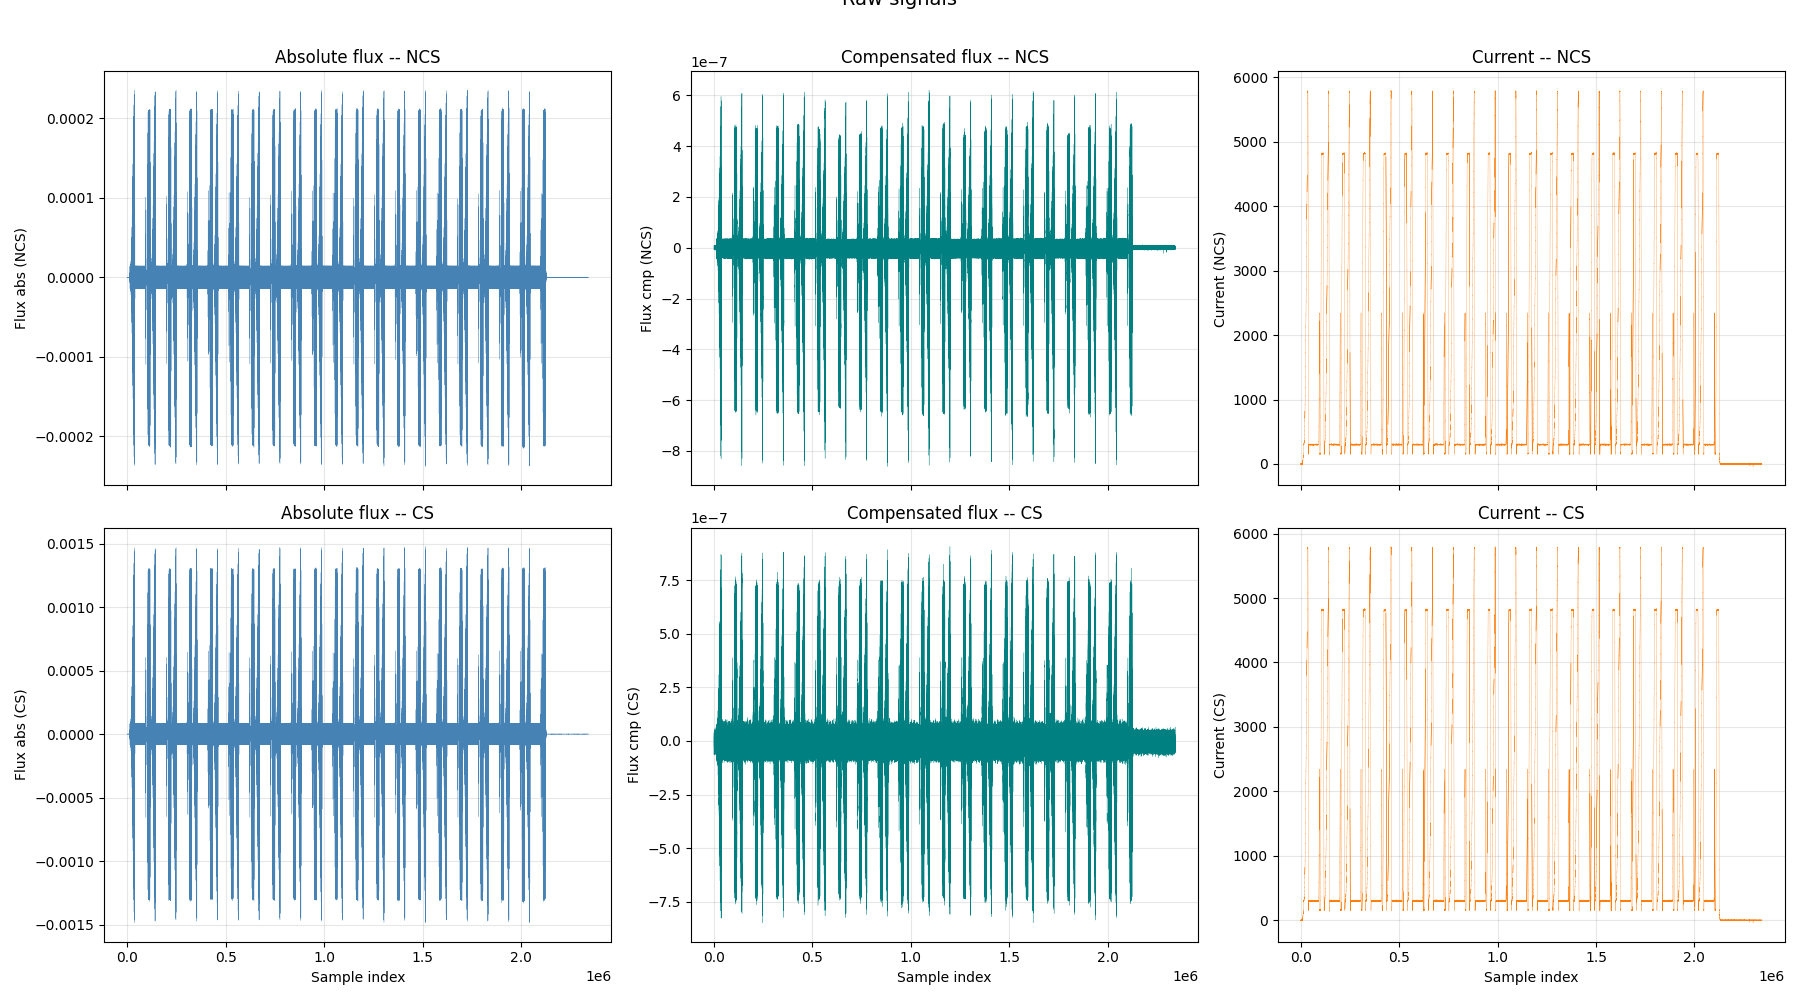

In [5]:
fig, axes = plt.subplots(len(SEGMENTS), 3, figsize=(18, 5 * len(SEGMENTS)), sharex="col")
if len(SEGMENTS) == 1:
    axes = axes[np.newaxis, :]

for i, seg in enumerate(SEGMENTS):
    d = data[seg]
    n_keep = d["n_turns"] * Ns
    x = np.arange(n_keep)
    axes[i, 0].plot(x, d["flux_abs"].ravel(), linewidth=0.2, color="steelblue")
    axes[i, 0].set_ylabel(f"Flux abs ({seg})")
    axes[i, 0].set_title(f"Absolute flux -- {seg}")
    axes[i, 1].plot(x, d["flux_cmp"].ravel(), linewidth=0.2, color="teal")
    axes[i, 1].set_ylabel(f"Flux cmp ({seg})")
    axes[i, 1].set_title(f"Compensated flux -- {seg}")
    axes[i, 2].plot(x, d["I_all"].ravel(), linewidth=0.2, color="tab:orange")
    axes[i, 2].set_ylabel(f"Current ({seg})")
    axes[i, 2].set_title(f"Current -- {seg}")

axes[-1, 0].set_xlabel("Sample index")
axes[-1, 1].set_xlabel("Sample index")
axes[-1, 2].set_xlabel("Sample index")
fig.suptitle("Raw signals", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

---
## 5. cel/fed Safety Diagnostic

Run `diagnose_cel_fed()` on NCS high-current turns.

In [6]:
# Diagnostic on main segment (not fringe)
_main_seg = "NCS"
d = data[_main_seg]
I_mean = d["I_all"].mean(axis=1)
hi_mask = np.abs(I_mean) > np.percentile(np.abs(I_mean), 90)
if hi_mask.sum() < 5:
    hi_mask = np.abs(I_mean) > np.median(np.abs(I_mean))

n_diag = min(100, int(hi_mask.sum()))
hi_idx = np.where(hi_mask)[0][:n_diag]

diag = diagnose_cel_fed(
    d["flux_abs"][hi_idx], d["flux_cmp"][hi_idx],
    d["t_all"][hi_idx], d["I_all"][hi_idx],
    kn=KN[_main_seg], r_ref=R_REF, magnet_order=MAGNET_ORDER,
)
print(f"cel/fed diagnostic ({n_diag} {_main_seg} high-I turns):")
print(f"  Recommendation: {diag.recommendation}")
print(f"  {diag.reason}")
Bd = np.max(np.abs(diag.B_main_with_fed - diag.B_main_without_fed))
print(f"  B_main max |diff|: {Bd:.4e} T")

if diag.recommendation == "UNSAFE":
    OPTIONS = tuple(o for o in OPTIONS if o not in ("cel", "fed"))
    print(f"  -> cel/fed disabled, OPTIONS = {OPTIONS}")
else:
    print(f"  -> cel/fed safe, keeping OPTIONS = {OPTIONS}")

cel/fed diagnostic (100 NCS high-I turns):
  Recommendation: UNSAFE
  98/100 turns (98%) have |zR| > 0.0100 (median 0.0718, max 0.5162). cel/fed produces unreliable offsets — skip it and use OPTIONS = ('dri', 'rot').
  B_main max |diff|: 6.6376e-04 T
  -> cel/fed disabled, OPTIONS = ('dri', 'rot')


---
## 6. Plateau Detection & Turn Classification


NCS: 1447 plateau, 35 inj groups, 21 flat-high groups
  injection   : 1015 turns, I = 301.0 +/- 0.3 A
  flat-high   :  176 turns, I = 4831.0 +/- 125.1 A
  ramp        :  841 turns

CS [FRINGE]: 1447 plateau, 35 inj groups, 21 flat-high groups
  injection   : 1015 turns, I = 301.0 +/- 0.3 A
  flat-high   :  176 turns, I = 4831.0 +/- 125.1 A
  ramp        :  841 turns


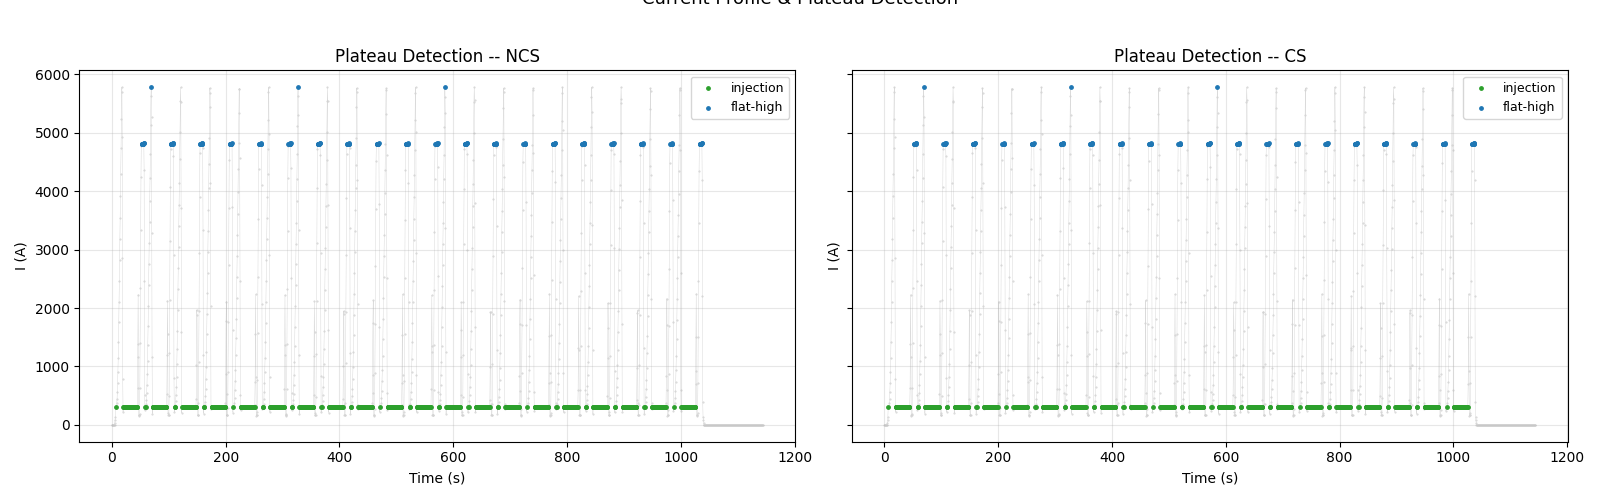

In [7]:
label_colors = {"injection": "tab:green", "flat-mid": "tab:purple", "flat-high": "tab:blue"}

for seg in SEGMENTS:
    d = data[seg]
    I_mean = d["I_all"].mean(axis=1)
    t_mean = d["t_all"].mean(axis=1)
    I_range, I_blocks = compute_block_averaged_range(d["I_all"], Ns, N_BLOCKS)

    plateau_info = detect_plateau_turns(I_blocks, I_mean, I_range, PLATEAU_I_RANGE_MAX)
    is_plateau = plateau_info["is_plateau"]

    turn_label = np.array(["ramp"] * d["n_turns"], dtype=object)
    for j in range(d["n_turns"]):
        if is_plateau[j]:
            turn_label[j] = classify_current(I_mean[j])

    inj_groups = find_contiguous_groups(turn_label == "injection", min_length=2)
    fh_groups = find_contiguous_groups(turn_label == "flat-high", min_length=2)

    d.update({
        "I_mean": I_mean, "t_mean": t_mean, "I_range": I_range,
        "is_plateau": is_plateau, "turn_label": turn_label,
        "inj_groups": inj_groups, "fh_groups": fh_groups,
    })

    _scfg = next(sc for sc in SEGMENT_CONFIGS if sc["name"] == seg)
    fringe = " [FRINGE]" if _scfg["is_fringe"] else ""
    print(f"\n{seg}{fringe}: {is_plateau.sum()} plateau, "
          f"{len(inj_groups)} inj groups, {len(fh_groups)} flat-high groups")
    for lab in ["injection", "flat-mid", "flat-high"]:
        mask = turn_label == lab
        if mask.sum() > 0:
            print(f"  {lab:12s}: {mask.sum():4d} turns, I = {I_mean[mask].mean():.1f} +/- {I_mean[mask].std():.1f} A")
    print(f"  {'ramp':12s}: {(turn_label == 'ramp').sum():4d} turns")

# Plot
fig, axes = plt.subplots(1, len(SEGMENTS), figsize=(8 * len(SEGMENTS), 5), sharey=True)
if len(SEGMENTS) == 1:
    axes = [axes]
for ax, seg in zip(axes, SEGMENTS):
    d = data[seg]
    ax.plot(d["t_mean"], d["I_mean"], ".-", markersize=1, linewidth=0.3, color="lightgrey", zorder=0)
    for lab, col in label_colors.items():
        mask = d["turn_label"] == lab
        idx = np.where(mask)[0]
        if len(idx) > 0:
            ax.scatter(d["t_mean"][idx], d["I_mean"][idx], s=6, color=col, zorder=2, label=lab)
    ax.set_xlabel("Time (s)"); ax.set_ylabel("I (A)")
    ax.set_title(f"Plateau Detection -- {seg}"); ax.legend(fontsize=9)
fig.suptitle("Current Profile & Plateau Detection", fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

---
## 7. FDI Stuck-Channel Diagnostic

Check whether the FDI responds to current changes between plateau groups.

In [8]:
for seg in SEGMENTS:
    d = data[seg]
    # Build run_info from contiguous plateau groups
    all_groups = []
    for lab_name in ["injection", "flat-mid", "flat-high"]:
        groups = find_contiguous_groups(d["turn_label"] == lab_name, min_length=2)
        for gs, ge in groups:
            all_groups.append({"start": gs, "end": ge,
                               "I_nom": float(d["I_mean"][gs:ge+1].mean())})
    all_groups.sort(key=lambda x: x["start"])
    for i, g in enumerate(all_groups):
        g["run_id"] = i

    if len(all_groups) < 2:
        print(f"{seg}: fewer than 2 plateau groups, skipping FDI check")
        continue

    flux_turns = d["flux_abs"].mean(axis=1)
    checks = diagnose_fdi_transitions(
        flux_turns, d["I_mean"], all_groups,
        stuck_threshold=0.3, partial_threshold=0.7, min_delta_I=5.0,
    )
    n_ok = sum(1 for c in checks if c.severity == "OK")
    n_stuck = sum(1 for c in checks if c.severity == "STUCK")
    print(f"\n{seg}: {len(checks)} transitions, OK={n_ok}, STUCK={n_stuck}")
    for c in checks:
        if c.severity != "OK":
            print(f"  ! Run {c.run_before}->{c.run_after}: {c.severity} -- {c.reason}")
    if n_stuck > 0:
        print(f"  WARNING: {n_stuck} stuck transitions!")
    else:
        print(f"  All transitions OK.")


NCS: 39 transitions, OK=39, STUCK=0
  All transitions OK.



CS: 39 transitions, OK=39, STUCK=0
  All transitions OK.


---
## 8. Process Plateau Turns

Re-process plateau turns with the full pipeline. Group by supercycle/run, apply settling window and MAD sigma-clip.

In [9]:
ANALYSIS_LABELS = {"injection", "flat-mid", "flat-high"}

results = {}

for seg in SEGMENTS:
    d = data[seg]
    turn_label = d["turn_label"]
    kn_seg = KN[seg]

    is_analysis = np.array([l in ANALYSIS_LABELS for l in turn_label])
    plateau_indices = np.where(is_analysis)[0]
    print(f"\n{seg}: processing {len(plateau_indices)} plateau turns (OPTIONS={OPTIONS})")

    result, C_merged, C_units, ok_main = process_kn_pipeline(
        flux_abs_turns=d["flux_abs"][plateau_indices],
        flux_cmp_turns=d["flux_cmp"][plateau_indices],
        t_turns=d["t_all"][plateau_indices],
        I_turns=d["I_all"][plateau_indices],
        kn=kn_seg, r_ref=R_REF, magnet_order=m,
        options=OPTIONS, min_b1_T=MIN_B1_T,
    )

    extra = [
        {"global_turn": int(plateau_indices[t]),
          "label": str(turn_label[plateau_indices[t]]),
          "I_range_A": float(d["I_range"][plateau_indices[t]]),
          "segment": seg}
        for t in range(len(plateau_indices))
    ]

    rows = build_harmonic_rows(result, C_merged, C_units, ok_main, m, extra)
    df = pd.DataFrame(rows)

    # Group by supercycle
    df["sc_idx"] = -1
    settled_idx = []

    for gi, (gs, ge) in enumerate(d["inj_groups"]):
        group_globals = set(range(gs, ge + 1))
        gmask = df["global_turn"].isin(group_globals) & (df["label"] == "injection")
        df.loc[gmask, "sc_idx"] = gi
        group_rows = df.index[gmask]
        if N_LAST_TURNS_INJ is not None and len(group_rows) > N_LAST_TURNS_INJ:
            settled_idx.extend(group_rows[-N_LAST_TURNS_INJ:])
        else:
            settled_idx.extend(group_rows)

    for gi, (gs, ge) in enumerate(d["fh_groups"]):
        group_globals = set(range(gs, ge + 1))
        gmask = df["global_turn"].isin(group_globals) & (df["label"] == "flat-high")
        df.loc[gmask, "sc_idx"] = gi
        group_rows = df.index[gmask]
        if N_LAST_TURNS_HIGH is not None and len(group_rows) > N_LAST_TURNS_HIGH:
            settled_idx.extend(group_rows[-N_LAST_TURNS_HIGH:])
        else:
            settled_idx.extend(group_rows)

    df_settled = df.loc[sorted(settled_idx)].copy()

    n_before = len(df_settled)
    df_settled, clip_info = mad_sigma_clip(df_settled, "B1_T", N_SIGMA_CLIP, label_col="label")
    n_clipped = n_before - len(df_settled)
    if n_clipped > 0:
        print(f"  Sigma clip ({N_SIGMA_CLIP} MAD sigma): removed {n_clipped} turns ({clip_info})")

    df["TF_TperkA"] = df["B1_T"] / (df["I_mean_A"] / 1000.0)
    df_settled["TF_TperkA"] = df_settled["B1_T"] / (df_settled["I_mean_A"] / 1000.0)

    results[seg] = {"df": df, "df_settled": df_settled}

    print(f"  {seg}: {len(df)} all plateau, {len(df_settled)} settled")
    for lab in ["injection", "flat-high"]:
        n_all = len(df[df["label"] == lab])
        n_set = len(df_settled[df_settled["label"] == lab])
        print(f"    {lab:12s}: {n_all} -> {n_set}")


NCS: processing 1191 plateau turns (OPTIONS=('dri', 'rot'))


  Sigma clip (5.0 MAD sigma): removed 31 turns ({'injection': 31})
  NCS: 1191 all plateau, 532 settled


    injection   : 1015 -> 359
    flat-high   : 176 -> 173

CS: processing 1191 plateau turns (OPTIONS=('dri', 'rot'))
  Sigma clip (5.0 MAD sigma): removed 32 turns ({'injection': 32})
  CS: 1191 all plateau, 531 settled
    injection   : 1015 -> 358
    flat-high   : 176 -> 173


---
## 9. All-Turn Harmonics vs Time

Process all turns (including ramps) to show B1, b2, b3 evolution.

NCS: 2288 all-turns processed, ok_main=2268


CS: 2288 all-turns processed, ok_main=2288


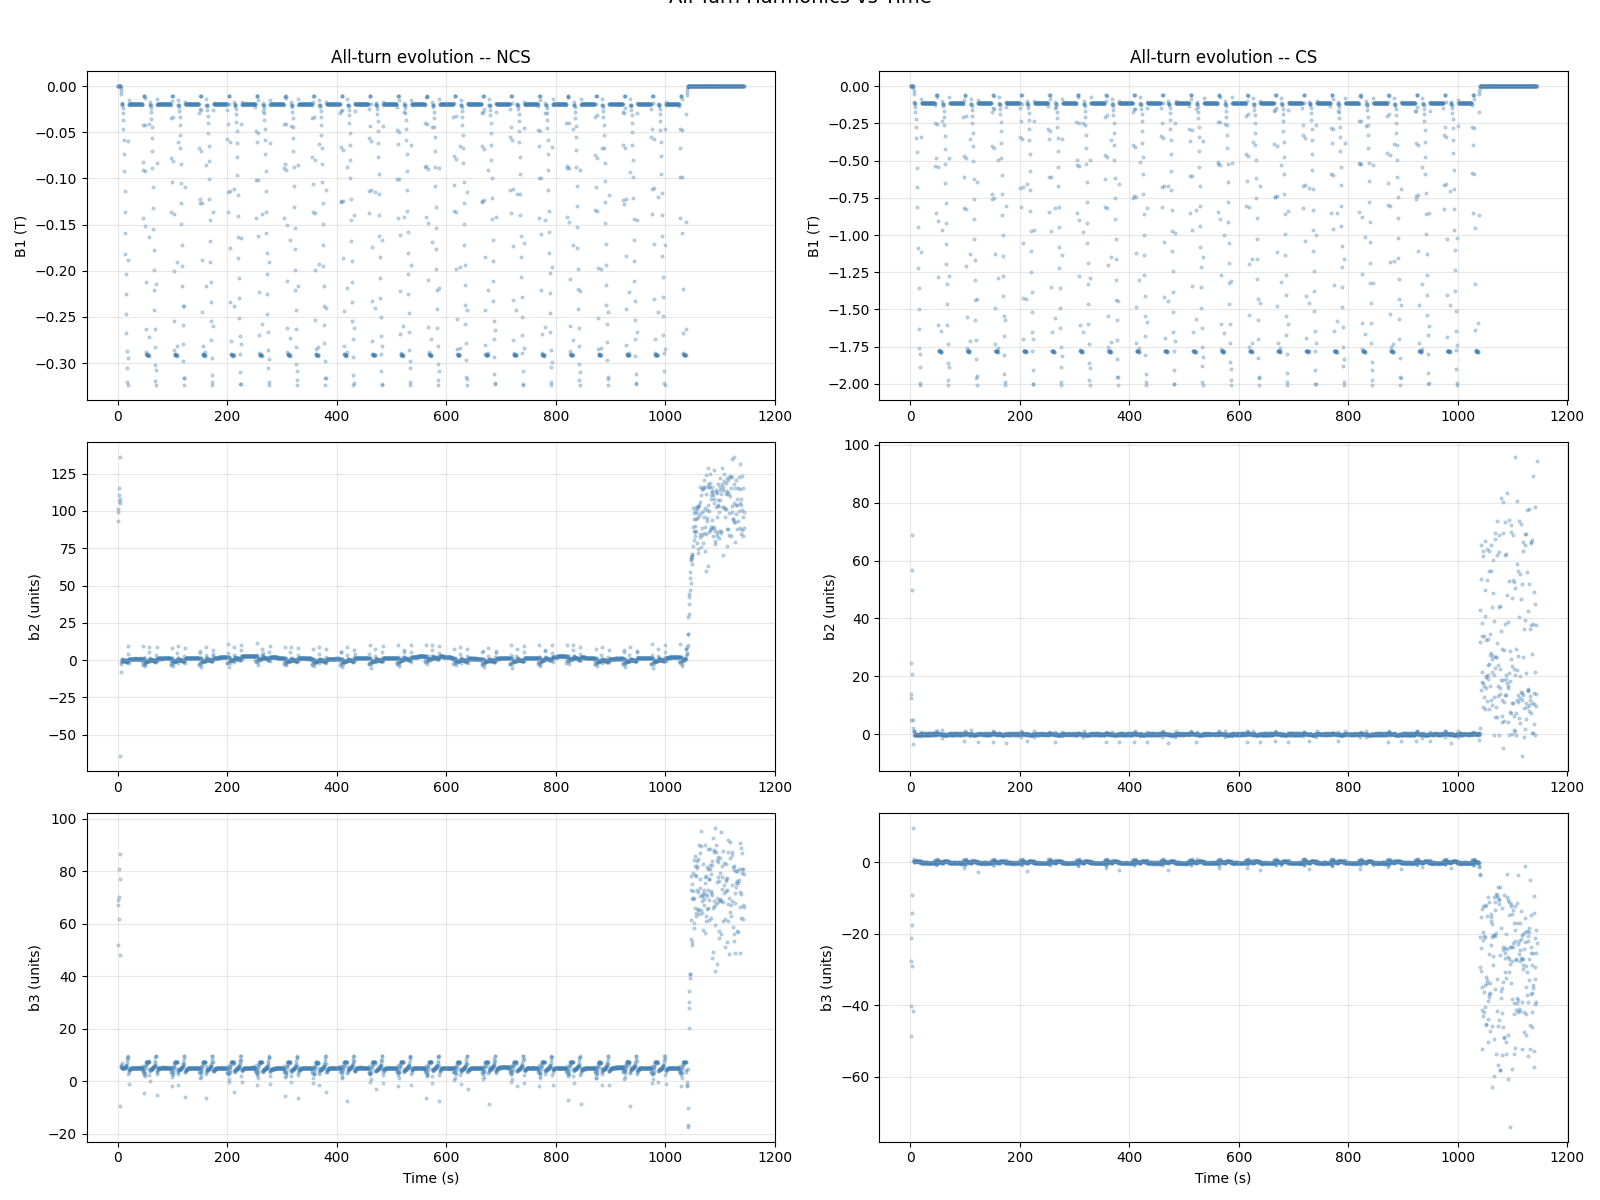

In [10]:
all_turn_dfs = {}

for seg in SEGMENTS:
    d = data[seg]
    kn_seg = KN[seg]

    result_all, C_merged_all, C_units_all, ok_main_all = process_kn_pipeline(
        flux_abs_turns=d["flux_abs"], flux_cmp_turns=d["flux_cmp"],
        t_turns=d["t_all"], I_turns=d["I_all"],
        kn=kn_seg, r_ref=R_REF, magnet_order=m,
        options=OPTIONS, min_b1_T=MIN_B1_T,
    )

    extra_all = [{"global_turn": int(i), "segment": seg} for i in range(d["n_turns"])]
    rows_all = build_harmonic_rows(result_all, C_merged_all, C_units_all, ok_main_all, m, extra_all)
    df_all = pd.DataFrame(rows_all)
    df_all["t_mean_s"] = d["t_mean"]
    all_turn_dfs[seg] = df_all
    print(f"{seg}: {d['n_turns']} all-turns processed, ok_main={ok_main_all.sum()}")

# Plot B1, b2, b3 vs time
fig, axes = plt.subplots(3, len(SEGMENTS), figsize=(8 * len(SEGMENTS), 12))
if len(SEGMENTS) == 1:
    axes = axes[:, np.newaxis]

for j, seg in enumerate(SEGMENTS):
    df_all = all_turn_dfs[seg]
    ok = df_all["ok_main"]
    for ax_idx, (col, ylabel) in enumerate([("B1_T", "B1 (T)"), ("b2_units", "b2 (units)"), ("b3_units", "b3 (units)")]):
        ax = axes[ax_idx, j]
        ax.scatter(df_all.loc[ok, "t_mean_s"], df_all.loc[ok, col],
                   s=4, alpha=0.3, color="steelblue", zorder=1)
        ax.set_ylabel(ylabel)
        if ax_idx == 0:
            ax.set_title(f"All-turn evolution -- {seg}")
        if ax_idx == 2:
            ax.set_xlabel("Time (s)")

fig.suptitle("All-Turn Harmonics vs Time", fontsize=14, y=1.01)
plt.tight_layout(); plt.show()

---
## 10. FFMM Golden Standard Validation

Compare pipeline output against FFMM per-turn and average results.

In [11]:
OPTIONS_FFMM = ('dri', 'rot')
FFMM_ROTATE_EXCLUDES_LAST = True

print("=" * 70)
print("FFMM GOLDEN STANDARD COMPARISON")
print(f"FFMM pipeline options: {OPTIONS_FFMM}")
print(f"legacy_rotate_excludes_last = {FFMM_ROTATE_EXCLUDES_LAST}")
print("=" * 70)

# This section expects FFMM result files alongside the raw data.
# Adjust paths as needed for your measurement.
print("(FFMM validation section -- configure paths for your measurement)")

FFMM GOLDEN STANDARD COMPARISON
FFMM pipeline options: ('dri', 'rot')
legacy_rotate_excludes_last = True
(FFMM validation section -- configure paths for your measurement)


---
## 11. Main Field (B1)

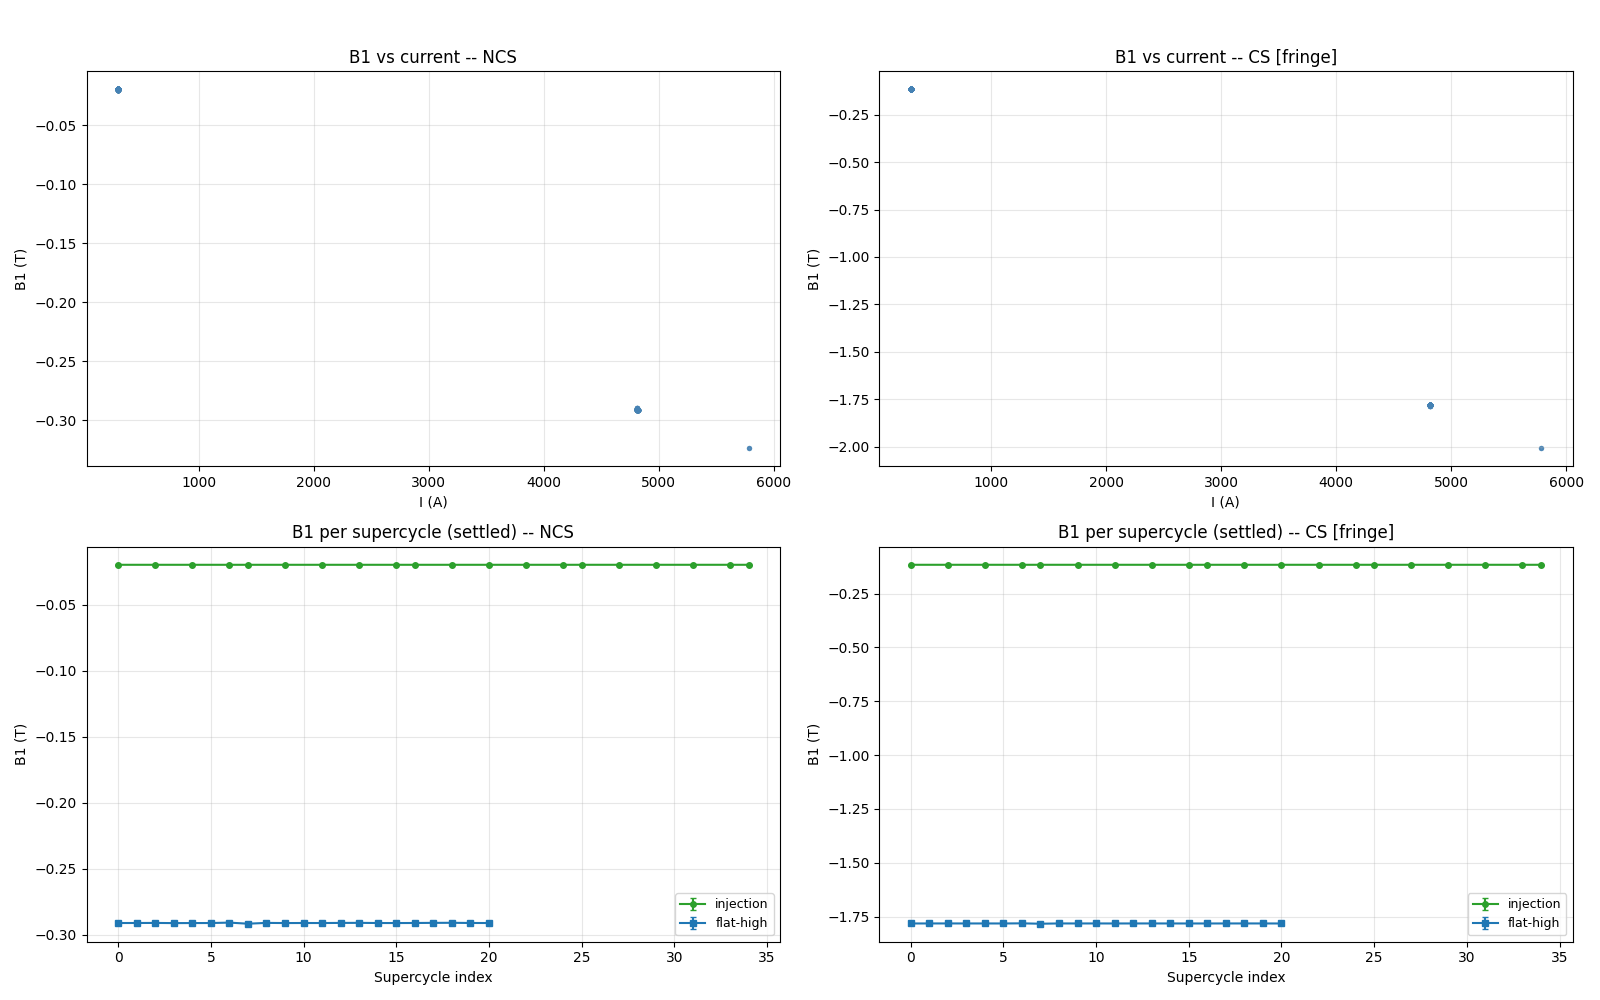


B1 per operating point (settled turns):
  NCS injection   : N= 359, mean=-0.019622, std=0.000003
  NCS flat-high   : N= 173, mean=-0.291179, std=0.000520
  CS injection   : N= 358, mean=-0.116255, std=0.000006
  CS flat-high   : N= 173, mean=-1.781715, std=0.000901


In [12]:
fig, axes = plt.subplots(2, len(SEGMENTS), figsize=(8 * len(SEGMENTS), 10))
if len(SEGMENTS) == 1:
    axes = axes[:, np.newaxis]

for j, seg in enumerate(SEGMENTS):
    df = results[seg]["df"]
    df_settled = results[seg]["df_settled"]
    ok = df["ok_main"]
    _scfg = next(sc for sc in SEGMENT_CONFIGS if sc["name"] == seg)
    fringe = " [fringe]" if _scfg["is_fringe"] else ""

    ax = axes[0, j]
    ax.scatter(df.loc[ok, "I_mean_A"], df.loc[ok, "B1_T"], s=8, alpha=0.5, color="steelblue")
    
    ax.set_xlabel("I (A)"); ax.set_ylabel("B1 (T)")
    ax.set_title(f"B1 vs current -- {seg}{fringe}")

    ax = axes[1, j]
    for lab, col, marker in [("injection", "tab:green", "o"), ("flat-high", "tab:blue", "s")]:
        sub = df_settled[(df_settled["label"] == lab) & df_settled["ok_main"]]
        if len(sub) > 0:
            sc_avg = sub.groupby("sc_idx")["B1_T"].agg(["mean", "std"]).reset_index()
            ax.errorbar(sc_avg["sc_idx"], sc_avg["mean"], yerr=sc_avg["std"],
                        fmt=f"{marker}-", markersize=4, capsize=2, color=col, label=lab)
    
    ax.set_xlabel("Supercycle index"); ax.set_ylabel("B1 (T)")
    ax.set_title(f"B1 per supercycle (settled) -- {seg}{fringe}"); ax.legend(fontsize=9)

fig.suptitle("Main Field (B1)", fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

# Statistics
print("\nB1 per operating point (settled turns):")
for seg in SEGMENTS:
    df_settled = results[seg]["df_settled"]
    for lab in ["injection", "flat-high"]:
        sub = df_settled[(df_settled["label"] == lab) & df_settled["ok_main"]]
        if len(sub) > 0:
            print(f"  {seg} {lab:12s}: N={len(sub):4d}, mean={sub['B1_T'].mean():+.6f}, std={sub['B1_T'].std():.6f}")

---
## 12. b2 (Quadrupole) -- first allowed harmonic error

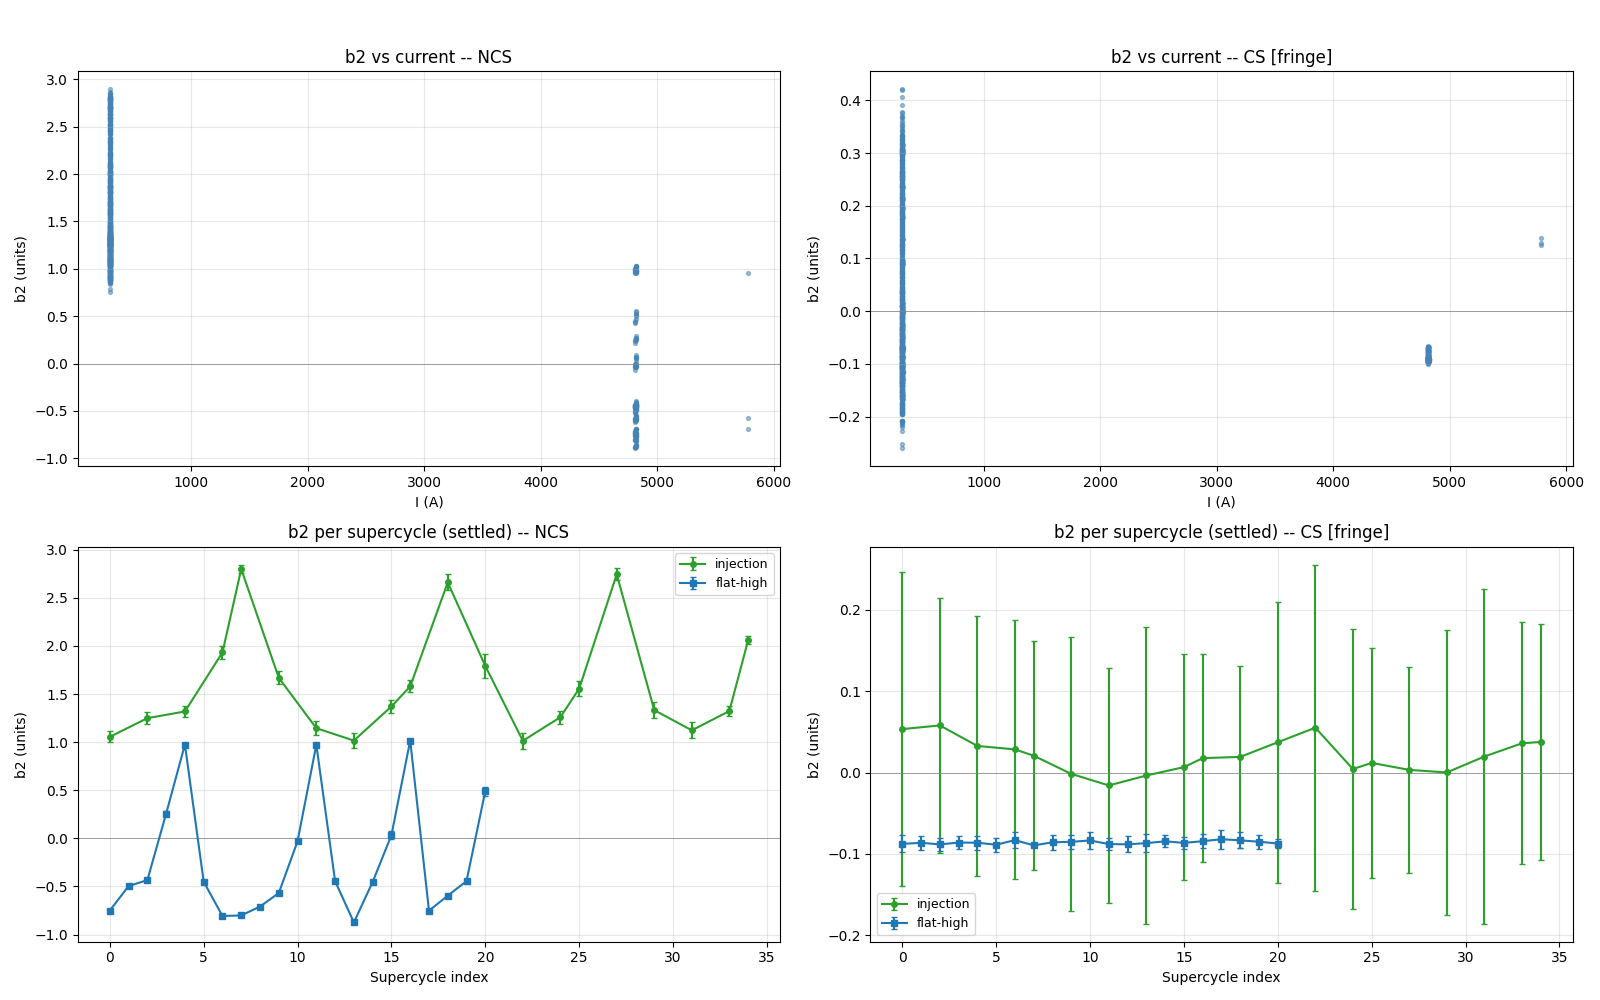


b2 per operating point (settled turns):
  NCS injection   : N= 359, mean=+1.600603, std=0.561238
  NCS flat-high   : N= 173, mean=-0.205451, std=0.611039
  CS injection   : N= 358, mean=+0.021044, std=0.157076
  CS flat-high   : N= 173, mean=-0.085886, std=0.008670


In [13]:
fig, axes = plt.subplots(2, len(SEGMENTS), figsize=(8 * len(SEGMENTS), 10))
if len(SEGMENTS) == 1:
    axes = axes[:, np.newaxis]

for j, seg in enumerate(SEGMENTS):
    df = results[seg]["df"]
    df_settled = results[seg]["df_settled"]
    ok = df["ok_main"]
    _scfg = next(sc for sc in SEGMENT_CONFIGS if sc["name"] == seg)
    fringe = " [fringe]" if _scfg["is_fringe"] else ""

    ax = axes[0, j]
    ax.scatter(df.loc[ok, "I_mean_A"], df.loc[ok, "b2_units"], s=8, alpha=0.5, color="steelblue")
    ax.axhline(0, color="grey", linewidth=0.5)
    ax.set_xlabel("I (A)"); ax.set_ylabel("b2 (units)")
    ax.set_title(f"b2 vs current -- {seg}{fringe}")

    ax = axes[1, j]
    for lab, col, marker in [("injection", "tab:green", "o"), ("flat-high", "tab:blue", "s")]:
        sub = df_settled[(df_settled["label"] == lab) & df_settled["ok_main"]]
        if len(sub) > 0:
            sc_avg = sub.groupby("sc_idx")["b2_units"].agg(["mean", "std"]).reset_index()
            ax.errorbar(sc_avg["sc_idx"], sc_avg["mean"], yerr=sc_avg["std"],
                        fmt=f"{marker}-", markersize=4, capsize=2, color=col, label=lab)
    ax.axhline(0, color="grey", linewidth=0.5)
    ax.set_xlabel("Supercycle index"); ax.set_ylabel("b2 (units)")
    ax.set_title(f"b2 per supercycle (settled) -- {seg}{fringe}"); ax.legend(fontsize=9)

fig.suptitle("b2 (Quadrupole) -- first allowed harmonic error", fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

# Statistics
print("\nb2 per operating point (settled turns):")
for seg in SEGMENTS:
    df_settled = results[seg]["df_settled"]
    for lab in ["injection", "flat-high"]:
        sub = df_settled[(df_settled["label"] == lab) & df_settled["ok_main"]]
        if len(sub) > 0:
            print(f"  {seg} {lab:12s}: N={len(sub):4d}, mean={sub['b2_units'].mean():+.6f}, std={sub['b2_units'].std():.6f}")

---
## 13. b3 (Sextupole) -- first non-allowed harmonic

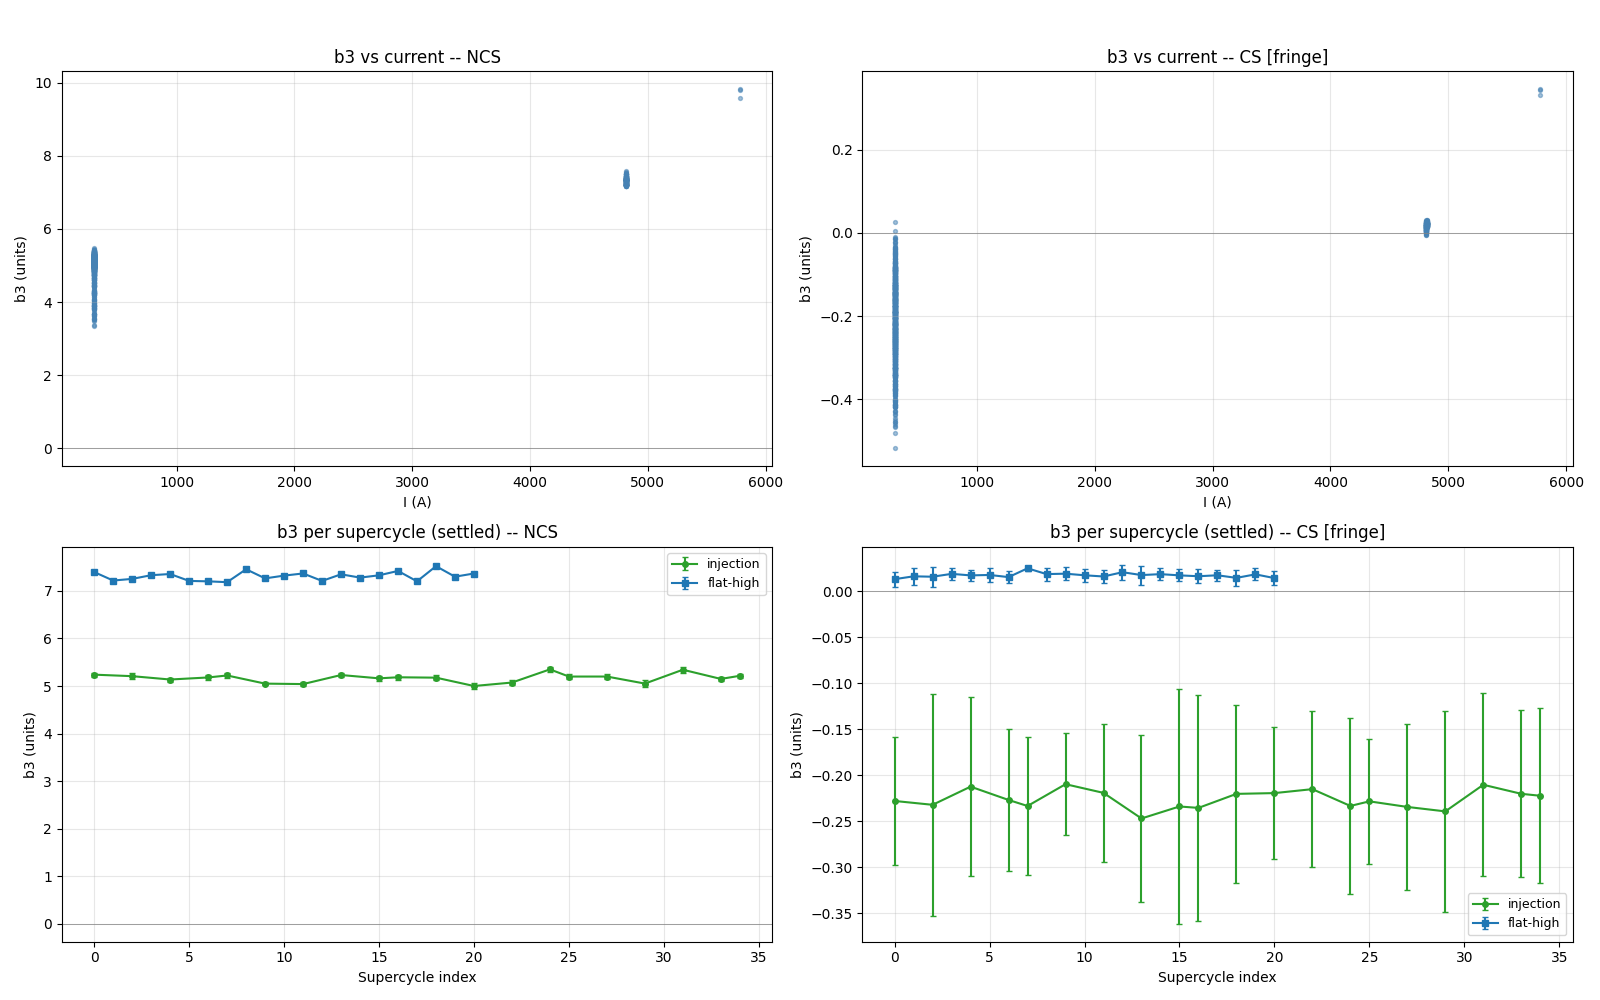


b3 per operating point (settled turns):
  NCS injection   : N= 359, mean=+5.170628, std=0.102708
  NCS flat-high   : N= 173, mean=+7.318386, std=0.091429
  CS injection   : N= 358, mean=-0.226131, std=0.090601
  CS flat-high   : N= 173, mean=+0.017139, std=0.007593


In [14]:
fig, axes = plt.subplots(2, len(SEGMENTS), figsize=(8 * len(SEGMENTS), 10))
if len(SEGMENTS) == 1:
    axes = axes[:, np.newaxis]

for j, seg in enumerate(SEGMENTS):
    df = results[seg]["df"]
    df_settled = results[seg]["df_settled"]
    ok = df["ok_main"]
    _scfg = next(sc for sc in SEGMENT_CONFIGS if sc["name"] == seg)
    fringe = " [fringe]" if _scfg["is_fringe"] else ""

    ax = axes[0, j]
    ax.scatter(df.loc[ok, "I_mean_A"], df.loc[ok, "b3_units"], s=8, alpha=0.5, color="steelblue")
    ax.axhline(0, color="grey", linewidth=0.5)
    ax.set_xlabel("I (A)"); ax.set_ylabel("b3 (units)")
    ax.set_title(f"b3 vs current -- {seg}{fringe}")

    ax = axes[1, j]
    for lab, col, marker in [("injection", "tab:green", "o"), ("flat-high", "tab:blue", "s")]:
        sub = df_settled[(df_settled["label"] == lab) & df_settled["ok_main"]]
        if len(sub) > 0:
            sc_avg = sub.groupby("sc_idx")["b3_units"].agg(["mean", "std"]).reset_index()
            ax.errorbar(sc_avg["sc_idx"], sc_avg["mean"], yerr=sc_avg["std"],
                        fmt=f"{marker}-", markersize=4, capsize=2, color=col, label=lab)
    ax.axhline(0, color="grey", linewidth=0.5)
    ax.set_xlabel("Supercycle index"); ax.set_ylabel("b3 (units)")
    ax.set_title(f"b3 per supercycle (settled) -- {seg}{fringe}"); ax.legend(fontsize=9)

fig.suptitle("b3 (Sextupole) -- first non-allowed harmonic", fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

# Statistics
print("\nb3 per operating point (settled turns):")
for seg in SEGMENTS:
    df_settled = results[seg]["df_settled"]
    for lab in ["injection", "flat-high"]:
        sub = df_settled[(df_settled["label"] == lab) & df_settled["ok_main"]]
        if len(sub) > 0:
            print(f"  {seg} {lab:12s}: N={len(sub):4d}, mean={sub['b3_units'].mean():+.6f}, std={sub['b3_units'].std():.6f}")

---
## 14. Higher Harmonics Overview

Statistics for all harmonics at key operating points (NCS).

In [15]:
seg = "NCS"
df_settled = results[seg]["df_settled"]
ok = df_settled["ok_main"]

for lab in ["injection", "flat-high"]:
    sub = df_settled[(df_settled["label"] == lab) & ok]
    if len(sub) == 0:
        continue
    print(f"\n=== {lab.upper()} (N={len(sub)} settled turns, {seg}) ===")
    print(f"  {'n':>3s} {'bn mean':>10s} {'bn std':>10s} {'an mean':>10s} {'an std':>10s}")
    print("  " + "-" * 50)
    for nn in range(2, H + 1):
        bn_col = f"b{nn}_units"
        an_col = f"a{nn}_units"
        if bn_col in sub.columns:
            bn_m, bn_s = sub[bn_col].mean(), sub[bn_col].std()
            an_m, an_s = sub[an_col].mean(), sub[an_col].std()
            flag = " *" if abs(bn_m) > 2 * bn_s and abs(bn_m) > 0.5 else ""
            print(f"  {nn:3d} {bn_m:+10.4f} {bn_s:10.4f} {an_m:+10.4f} {an_s:10.4f}{flag}")
    print("  (* = |mean| > 2*std and |mean| > 0.5 units)")


=== INJECTION (N=359 settled turns, NCS) ===
    n    bn mean     bn std    an mean     an std
  --------------------------------------------------
    2    +1.6006     0.5612    +9.0652     0.3754 *
    3    +5.1706     0.1027    -0.4465     0.0986 *
    4    +0.2112     0.1016    +0.6620     0.1081
    5    +0.3588     0.1045    +0.1969     0.1187
    6    +0.0535     0.1262    +0.0605     0.1506
    7    +0.2525     0.1702    +0.4098     0.2102
    8    -0.1233     0.2882    -0.0621     0.3350
    9    -0.2587     0.3924    -0.0820     0.4907
   10    -0.0164     0.6507    -0.0485     0.7548
   11    +0.0847     1.3156    +0.1100     1.4504
   12    +0.2894     5.4820    +0.1346     5.6669
   13    -0.0842     6.6296    +0.2561     6.3310
   14    +0.3571     3.2095    -0.1343     2.9506
   15    +0.5772     2.8759    -0.0450     2.3636
  (* = |mean| > 2*std and |mean| > 0.5 units)

=== FLAT-HIGH (N=173 settled turns, NCS) ===
    n    bn mean     bn std    an mean     an std
  ---

---
## 15. Multipole Spectrum

Bar charts of normal (bn) and skew (an) harmonics.

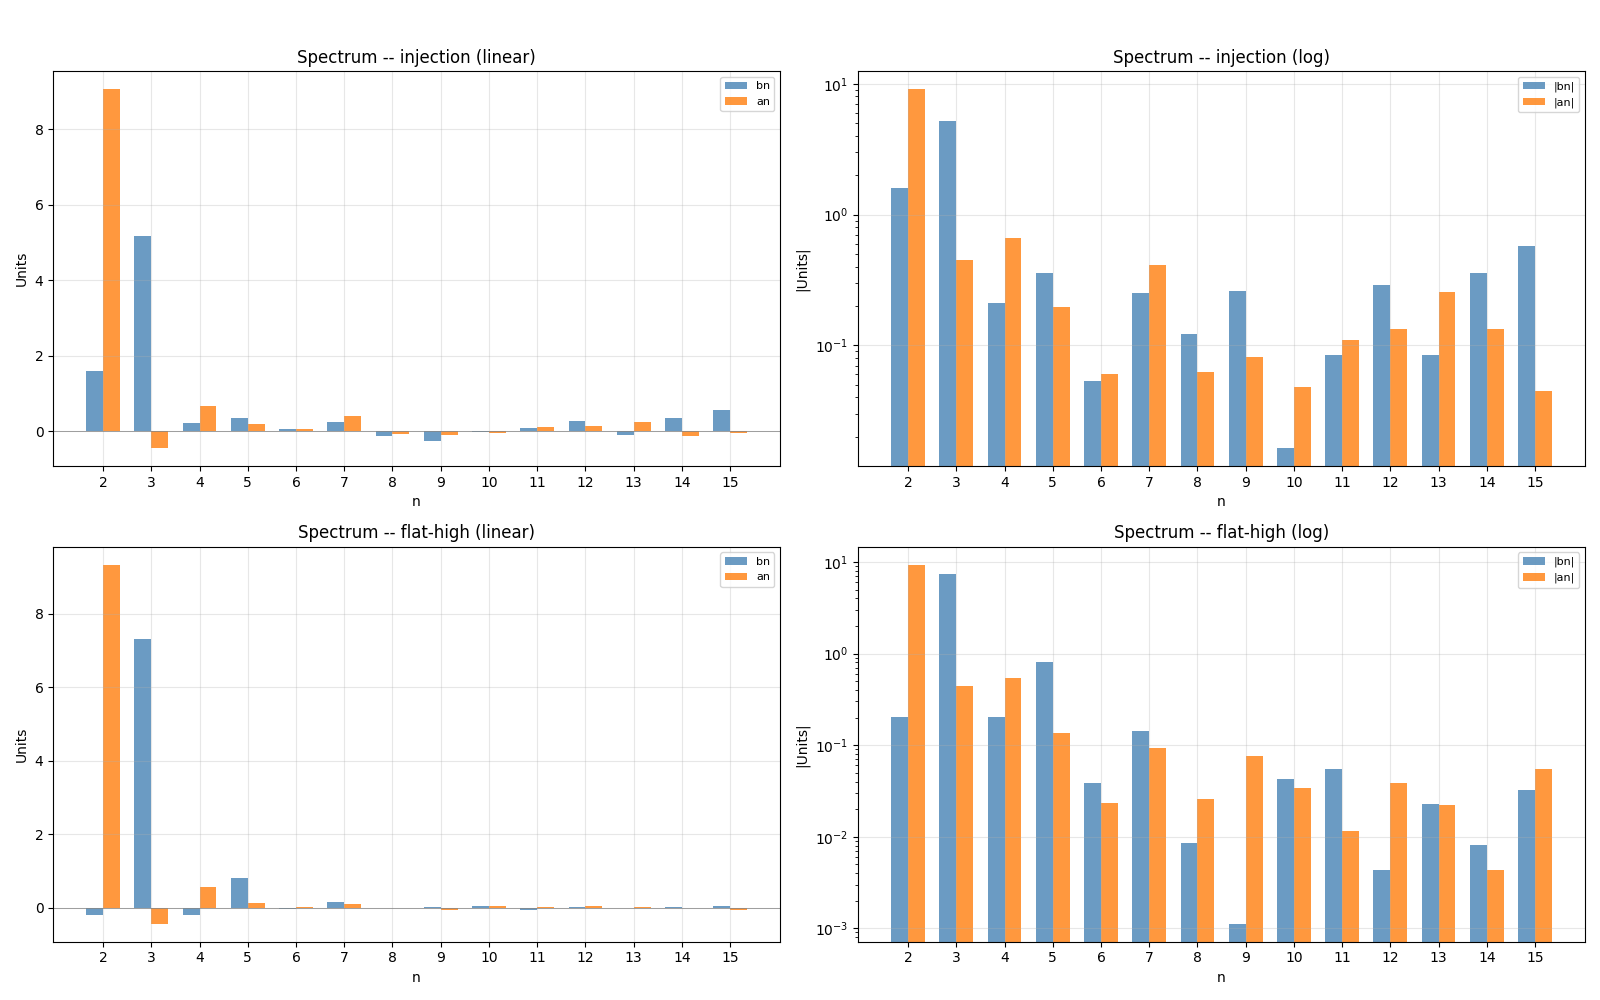

In [16]:
seg = "NCS"
df_settled = results[seg]["df_settled"]
ok = df_settled["ok_main"]

operating_points = {}
for lab in ["injection", "flat-high"]:
    sub = df_settled[(df_settled["label"] == lab) & ok]
    if len(sub) > 0:
        operating_points[lab] = sub

n_ops = len(operating_points)
if n_ops > 0:
    fig, axes = plt.subplots(n_ops, 2, figsize=(16, 5 * n_ops))
    if n_ops == 1:
        axes = axes[np.newaxis, :]

    for i, (lab, sub) in enumerate(operating_points.items()):
        orders = list(range(2, H + 1))
        bn_means = [sub[f"b{nn}_units"].mean() for nn in orders]
        an_means = [sub[f"a{nn}_units"].mean() for nn in orders]
        x = np.arange(len(orders))
        w = 0.35

        ax = axes[i, 0]
        ax.bar(x - w/2, bn_means, w, label="bn", color="steelblue", alpha=0.8)
        ax.bar(x + w/2, an_means, w, label="an", color="tab:orange", alpha=0.8)
        ax.axhline(0, color="grey", linewidth=0.5)
        ax.set_xticks(x); ax.set_xticklabels(orders)
        ax.set_xlabel("n"); ax.set_ylabel("Units")
        ax.set_title(f"Spectrum -- {lab} (linear)"); ax.legend(fontsize=8)

        ax = axes[i, 1]
        ax.bar(x - w/2, np.abs(bn_means), w, label="|bn|", color="steelblue", alpha=0.8)
        ax.bar(x + w/2, np.abs(an_means), w, label="|an|", color="tab:orange", alpha=0.8)
        ax.set_yscale("log")
        ax.set_xticks(x); ax.set_xticklabels(orders)
        ax.set_xlabel("n"); ax.set_ylabel("|Units|")
        ax.set_title(f"Spectrum -- {lab} (log)"); ax.legend(fontsize=8)

    fig.suptitle("Multipole Spectrum", fontsize=14, y=1.02)
    plt.tight_layout(); plt.show()
else:
    print("No operating points with data for spectrum plot.")

---
## 16. Transfer Function B1/I

TF = B1 / I (units: T/kA).

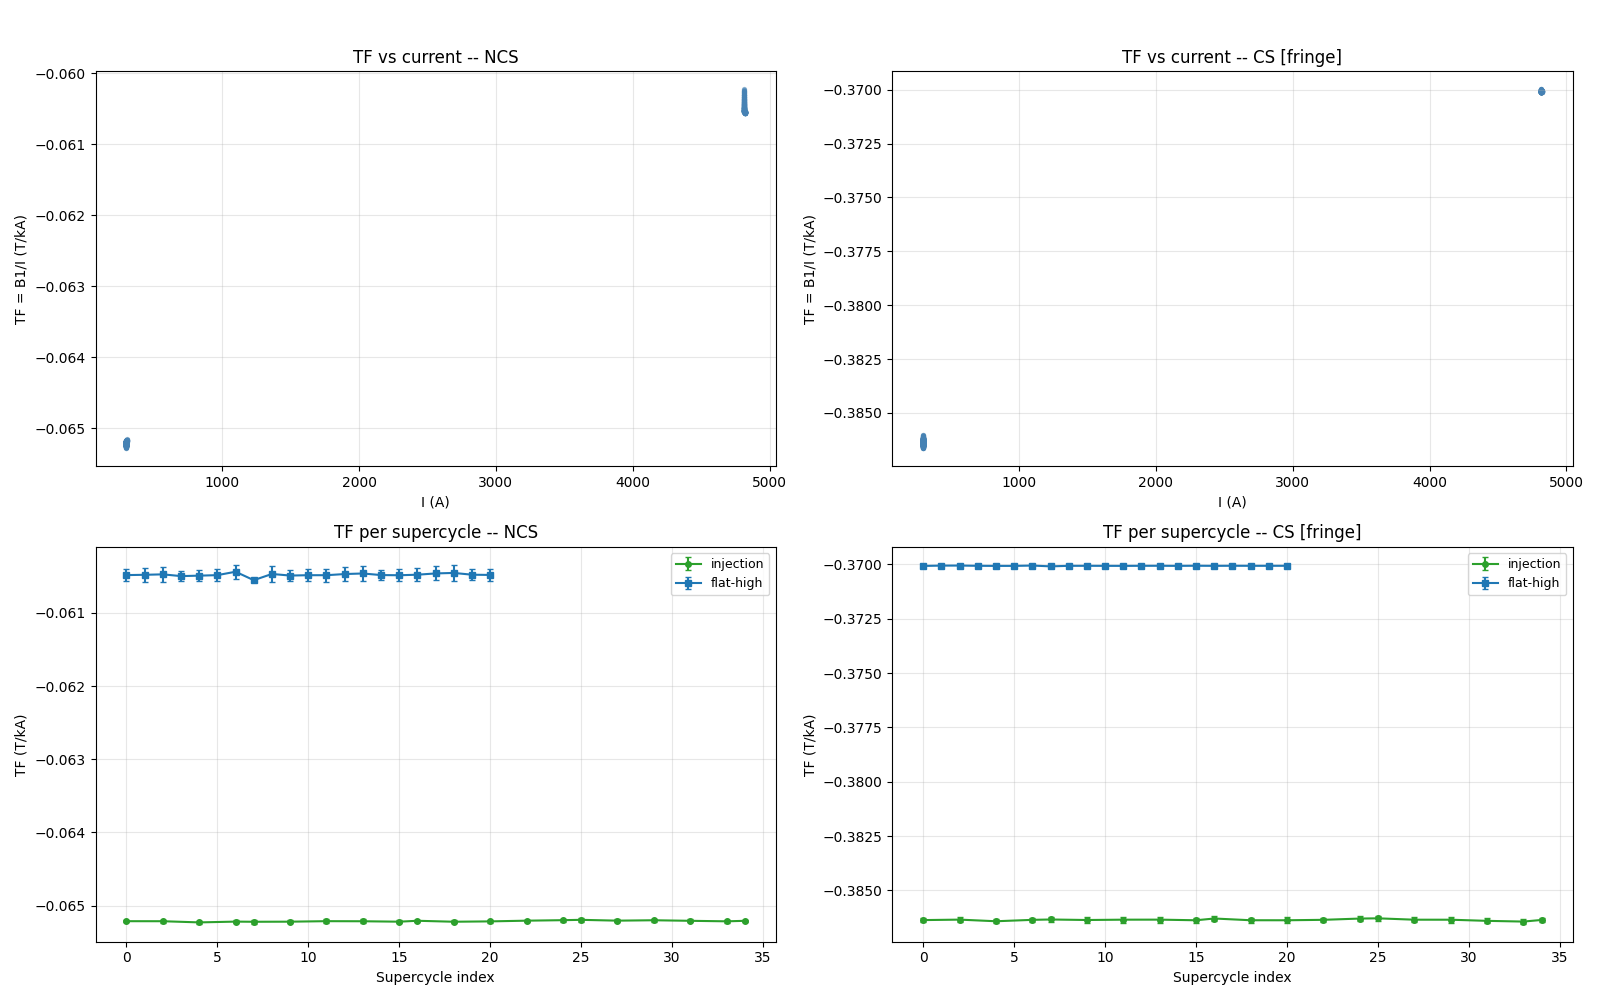

In [17]:
fig, axes = plt.subplots(2, len(SEGMENTS), figsize=(8 * len(SEGMENTS), 10))
if len(SEGMENTS) == 1:
    axes = axes[:, np.newaxis]

tf_summary = {}
for j, seg in enumerate(SEGMENTS):
    df_settled = results[seg]["df_settled"]
    ok = df_settled["ok_main"]
    _scfg = next(sc for sc in SEGMENT_CONFIGS if sc["name"] == seg)
    fringe = " [fringe]" if _scfg["is_fringe"] else ""

    ax = axes[0, j]
    sub_ok = df_settled[ok]
    ax.scatter(sub_ok["I_mean_A"], sub_ok["TF_TperkA"], s=8, alpha=0.5, color="steelblue")
    ax.set_xlabel("I (A)"); ax.set_ylabel("TF = B1/I (T/kA)")
    ax.set_title(f"TF vs current -- {seg}{fringe}")

    ax = axes[1, j]
    ds_tf = {}
    for lab, col, marker in [("injection", "tab:green", "o"), ("flat-high", "tab:blue", "s")]:
        sub = df_settled[(df_settled["label"] == lab) & ok]
        if len(sub) > 0:
            sc_avg = sub.groupby("sc_idx")["TF_TperkA"].agg(["mean", "std"]).reset_index()
            ax.errorbar(sc_avg["sc_idx"], sc_avg["mean"], yerr=sc_avg["std"],
                        fmt=f"{marker}-", markersize=4, capsize=2, color=col, label=lab)
            ds_tf[lab] = sc_avg
    ax.set_xlabel("Supercycle index"); ax.set_ylabel("TF (T/kA)")
    ax.set_title(f"TF per supercycle -- {seg}{fringe}"); ax.legend(fontsize=9)
    tf_summary[seg] = ds_tf

fig.suptitle("Transfer Function B1/I", fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

---
## 17. Apparent vs Differential Inductance

**L_app** = B1/I, **L_d** = dB1/dI (from paired current levels).

In [18]:
ld_results = {}
for seg in SEGMENTS:
    df_settled = results[seg]["df_settled"]
    ok = df_settled["ok_main"]
    df_inj = df_settled[(df_settled["label"] == "injection") & ok]
    df_fh = df_settled[(df_settled["label"] == "flat-high") & ok]

    if len(df_inj) == 0 or len(df_fh) == 0:
        ld_results[seg] = pd.DataFrame()
        continue

    inj_avg = df_inj.groupby("sc_idx").agg(
        B1_inj=("B1_T", "mean"), I_inj=("I_mean_A", "mean")).reset_index()
    fh_avg = df_fh.groupby("sc_idx").agg(
        B1_fh=("B1_T", "mean"), I_fh=("I_mean_A", "mean")).reset_index()

    merged = inj_avg.merge(fh_avg, on="sc_idx", how="inner")
    if len(merged) == 0:
        ld_results[seg] = pd.DataFrame()
        continue

    merged["Ld_TperkA"] = (merged["B1_fh"] - merged["B1_inj"]) / ((merged["I_fh"] - merged["I_inj"]) / 1000.0)
    ld_results[seg] = merged
    print(f"{seg}: {len(merged)} SC pairs, "
          f"Ld = {merged['Ld_TperkA'].mean():.4f} +/- {merged['Ld_TperkA'].std():.4f} T/kA")

print("\nSaturation check (Ld < L_app(FT) => saturated):")
for seg in SEGMENTS:
    m_df = ld_results.get(seg, pd.DataFrame())
    if len(m_df) == 0:
        continue
    Ld_mean = m_df["Ld_TperkA"].mean()
    fh = results[seg]["df_settled"]
    fh_ok = fh[(fh["label"] == "flat-high") & fh["ok_main"]]
    if len(fh_ok) > 0:
        Lapp_fh = fh_ok["TF_TperkA"].mean()
        ratio = Ld_mean / Lapp_fh
        verdict = "SATURATED" if ratio < 0.99 else "LINEAR"
        print(f"  {seg}: Ld={Ld_mean:.4f}, L_app(FT)={Lapp_fh:.4f}, ratio={ratio:.4f} -> {verdict}")

NCS: 12 SC pairs, Ld = -0.0602 +/- 0.0000 T/kA
CS: 12 SC pairs, Ld = -0.3690 +/- 0.0000 T/kA

Saturation check (Ld < L_app(FT) => saturated):
  NCS: Ld=-0.0602, L_app(FT)=-0.0605, ratio=0.9948 -> LINEAR
  CS: Ld=-0.3690, L_app(FT)=-0.3701, ratio=0.9971 -> LINEAR


---
## 18. Eddy Current Settling Analysis

Turn-by-turn B1 for all runs. Eddy currents cause exponential decay.

In [19]:
# Build per-supercycle injection data
eddy_data = {}

for seg in SEGMENTS:
    d = data[seg]
    df = results[seg]["df"]
    inj = df[df["label"] == "injection"].copy()
    if len(inj) == 0:
        eddy_data[seg] = pd.DataFrame()
        continue

    inj["t_mean_s"] = d["t_mean"][inj["global_turn"].values]
    for sc_id in inj["sc_idx"].unique():
        if sc_id < 0: continue
        mask = inj["sc_idx"] == sc_id
        t0 = inj.loc[mask, "t_mean_s"].min()
        inj.loc[mask, "t_since_inj_start"] = inj.loc[mask, "t_mean_s"] - t0

    for sc_id in inj["sc_idx"].unique():
        if sc_id < 0: continue
        mask = inj["sc_idx"] == sc_id
        inj.loc[mask, "turn_in_group"] = np.arange(mask.sum())

    eddy_data[seg] = inj
    print(f"{seg}: {len(inj)} injection turns across {inj['sc_idx'].nunique()} supercycles")

NCS: 1015 injection turns across 36 supercycles
CS: 1015 injection turns across 36 supercycles


### Raw B1 settling curves

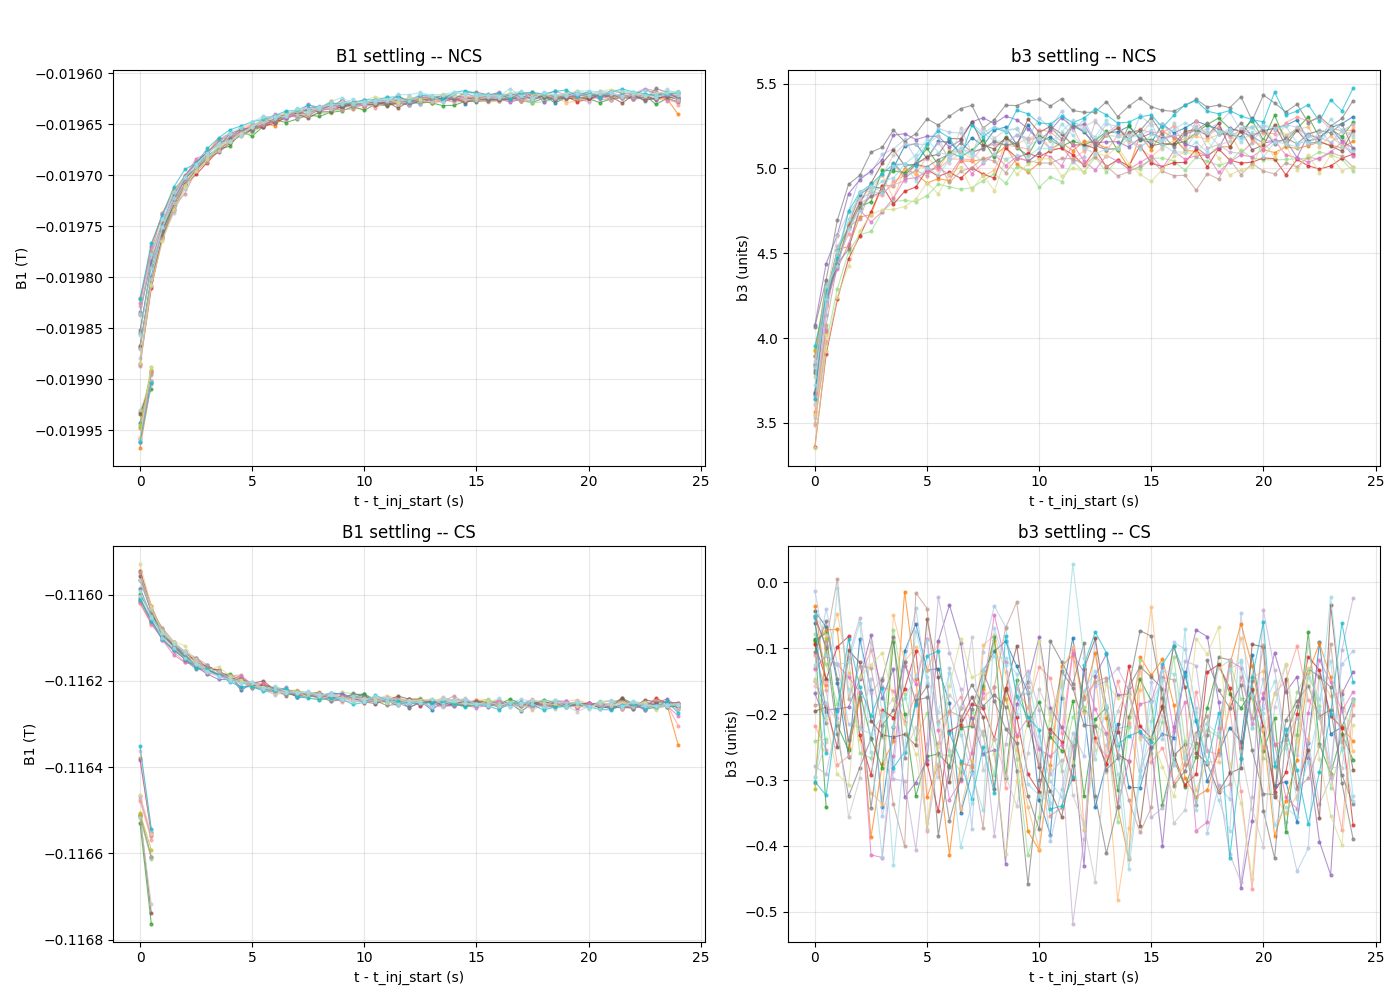

In [20]:
fig, axes = plt.subplots(len(SEGMENTS), 2, figsize=(14, 5 * len(SEGMENTS)))
if len(SEGMENTS) == 1:
    axes = axes[np.newaxis, :]

for i, seg in enumerate(SEGMENTS):
    inj = eddy_data[seg]
    for col_idx, (col, ylabel) in enumerate([("B1_T", "B1 (T)"), ("b3_units", "b3 (units)")]):
        ax = axes[i, col_idx]
        if len(inj) == 0:
            ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes)
            continue
        sc_ids = sorted([s for s in inj["sc_idx"].unique() if s >= 0])
        cmap = plt.cm.tab20(np.linspace(0, 1, max(len(sc_ids), 1)))
        for k, sc_id in enumerate(sc_ids):
            sub = inj[inj["sc_idx"] == sc_id]
            ax.plot(sub["t_since_inj_start"], sub[col], ".-",
                    markersize=4, linewidth=0.8, alpha=0.7, color=cmap[k % len(cmap)])
        ax.set_xlabel("t - t_inj_start (s)"); ax.set_ylabel(ylabel)
        ax.set_title(f"{ylabel.split()[0]} settling -- {seg}")

fig.suptitle("Injection Settling -- Supercycle Overlay", fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

---
## 19. Exponential Fits

Fit single-exponential eddy model per run/supercycle.

In [21]:
def fit_supercycle(df_sc):
    t = df_sc["t_since_inj_start"].values
    b3 = df_sc["b3_units"].values
    ok = np.isfinite(b3) & np.isfinite(t)
    t, b3 = t[ok], b3[ok]
    if len(t) < MIN_INJECTION_TURNS:
        return None
    try:
        popt, pcov = curve_fit(
            eddy_model, t, b3,
            p0=[b3[-1], b3[0] - b3[-1], max(t[-1] / 3, 1.0)],
            bounds=([-np.inf, -np.inf, 0.1], [np.inf, np.inf, 1000]),
            maxfev=5000,
        )
        perr = np.sqrt(np.diag(pcov))
        b3_pred = eddy_model(t, *popt)
        ss_res = np.sum((b3 - b3_pred) ** 2)
        ss_tot = np.sum((b3 - b3.mean()) ** 2)
        r2 = 1 - ss_res / ss_tot if ss_tot > 0 else 0
        return {"b3_inf": popt[0], "A": popt[1], "tau": popt[2],
                "b3_inf_err": perr[0], "A_err": perr[1], "tau_err": perr[2],
                "r2": r2, "n_turns": len(t)}
    except (RuntimeError, ValueError):
        return None

fit_results = {}
df_fits = {}
for seg in SEGMENTS:
    inj = eddy_data[seg]
    fits = []
    if len(inj) == 0:
        fit_results[seg] = fits
        df_fits[seg] = pd.DataFrame()
        continue
    for sc_id in sorted(inj["sc_idx"].unique()):
        if sc_id < 0: continue
        result = fit_supercycle(inj[inj["sc_idx"] == sc_id])
        if result is not None:
            result["supercycle_id"] = sc_id
            fits.append(result)
    fit_results[seg] = fits
    df_fits[seg] = pd.DataFrame(fits)
    print(f"{seg}: {len(fits)} supercycles fitted")

for seg, df_f in df_fits.items():
    if len(df_f) == 0: continue
    print(f"\n{seg}: tau mean={df_f['tau'].mean():.2f} s, R2 mean={df_f['r2'].mean():.3f}")

NCS: 20 supercycles fitted
CS: 20 supercycles fitted

NCS: tau mean=1.73 s, R2 mean=0.958

CS: tau mean=55.54 s, R2 mean=0.072


### Tau vs Current

In [22]:
print("Tau statistics:")
for seg in SEGMENTS:
    df_f = df_fits.get(seg, pd.DataFrame())
    if len(df_f) == 0: continue
    tau_v = df_f["tau"].values
    print(f"  {seg}: N={len(df_f)}, mean={tau_v.mean():.2f} s, std={tau_v.std():.2f} s")

Tau statistics:
  NCS: N=20, mean=1.73 s, std=0.34 s
  CS: N=20, mean=55.54 s, std=216.85 s


---
## 20. Settling Bias Analysis

How b2/b3 averages change with averaging window.

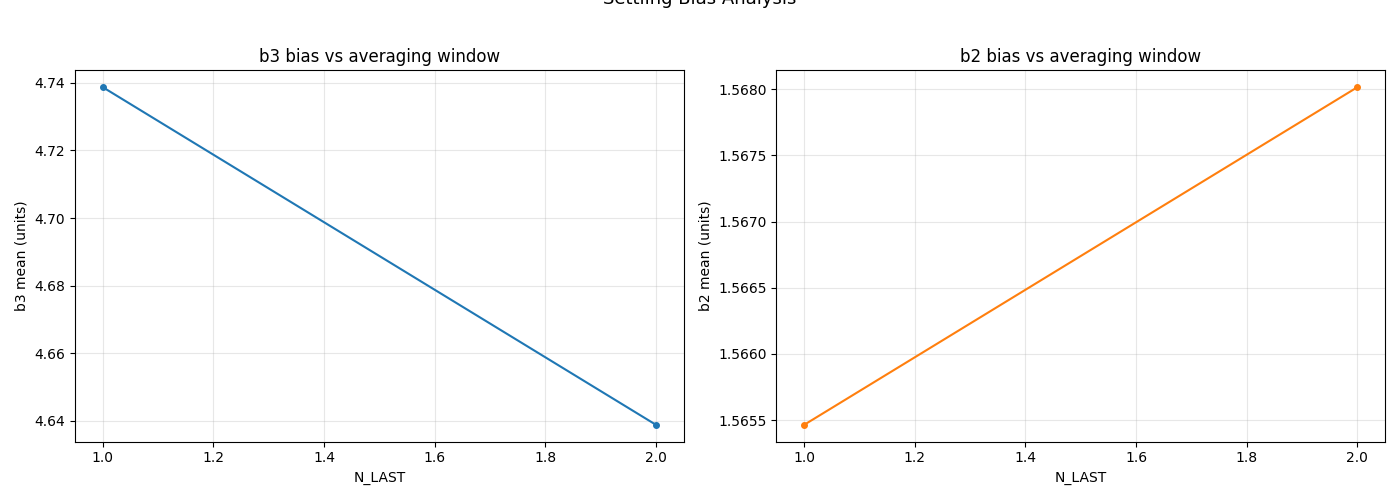

In [23]:
seg = "NCS"
inj = eddy_data[seg]
if len(inj) > 0 and "turn_in_group" in inj.columns:
    sc_ids = sorted([s for s in inj["sc_idx"].unique() if s >= 0])
    max_turns = inj.groupby("sc_idx").size().min()
    n_last_values = list(range(1, max_turns + 1))

    bias_b3, bias_b2 = [], []
    for n_last in n_last_values:
        b3_m, b2_m = [], []
        for sc_id in sc_ids:
            sub = inj[inj["sc_idx"] == sc_id].sort_values("turn_in_group")
            tail = sub.tail(n_last)
            if len(tail) > 0 and tail["ok_main"].any():
                ok_t = tail[tail["ok_main"]]
                b3_m.append(ok_t["b3_units"].mean())
                b2_m.append(ok_t["b2_units"].mean())
        bias_b3.append(np.mean(b3_m) if b3_m else np.nan)
        bias_b2.append(np.mean(b2_m) if b2_m else np.nan)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(n_last_values, bias_b3, "o-", markersize=4, color="tab:blue")
    axes[0].set_xlabel("N_LAST"); axes[0].set_ylabel("b3 mean (units)")
    axes[0].set_title("b3 bias vs averaging window")
    axes[1].plot(n_last_values, bias_b2, "o-", markersize=4, color="tab:orange")
    axes[1].set_xlabel("N_LAST"); axes[1].set_ylabel("b2 mean (units)")
    axes[1].set_title("b2 bias vs averaging window")
    fig.suptitle("Settling Bias Analysis", fontsize=13, y=1.02)
    plt.tight_layout(); plt.show()
else:
    print("No injection data for bias analysis.")

---
## 21. N_LAST Sensitivity Study

Scan N_LAST and show convergence.

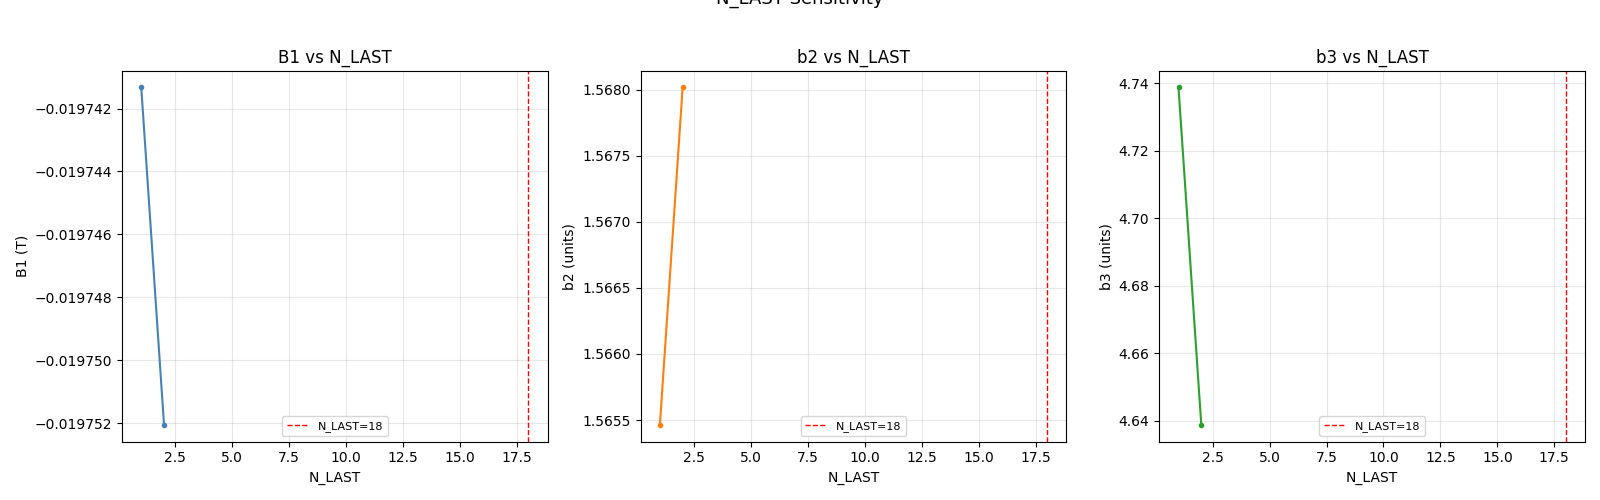

In [24]:
seg = "NCS"
d = data[seg]
_df = results[seg]["df"]
inj_all = _df[_df["label"] == "injection"].copy()

if len(inj_all) > 0:
    turns_per_sc = inj_all.groupby("sc_idx").size()
    max_n_last = int(turns_per_sc.min())
    n_last_scan = list(range(1, max_n_last + 1))

    scan_results = {"B1_T": [], "b2_units": [], "b3_units": []}
    for n_last in n_last_scan:
        settled_idx = []
        for sc_id in inj_all["sc_idx"].unique():
            if sc_id < 0: continue
            group_rows = inj_all.index[inj_all["sc_idx"] == sc_id]
            if len(group_rows) > n_last:
                settled_idx.extend(group_rows[-n_last:])
            else:
                settled_idx.extend(group_rows)
        sub = inj_all.loc[sorted(settled_idx)]
        sub_ok = sub[sub["ok_main"]]
        for col in ["B1_T", "b2_units", "b3_units"]:
            scan_results[col].append(sub_ok[col].mean() if len(sub_ok) > 0 else np.nan)

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    for ax, (col, ylabel, color) in zip(axes, [
            ("B1_T", "B1 (T)", "steelblue"),
            ("b2_units", "b2 (units)", "tab:orange"),
            ("b3_units", "b3 (units)", "tab:green")]):
        ax.plot(n_last_scan, scan_results[col], "o-", markersize=3, color=color)
        ax.axvline(N_LAST_TURNS_INJ, color="red", linestyle="--", linewidth=1,
                    label=f"N_LAST={N_LAST_TURNS_INJ}")
        ax.set_xlabel("N_LAST"); ax.set_ylabel(ylabel)
        ax.set_title(f"{ylabel.split()[0]} vs N_LAST"); ax.legend(fontsize=8)
    fig.suptitle("N_LAST Sensitivity", fontsize=13, y=1.02)
    plt.tight_layout(); plt.show()
else:
    print("No injection data for N_LAST sensitivity.")

---
## 22. Comprehensive Statistics Table

In [25]:
print("=" * 70)
print("SPS MBB Dipole -- 200 GeV MD1, 2 Hz")
print("=" * 70)
print(f"Options: {OPTIONS}")
print(f"cel/fed: {diag.recommendation}")

for seg in SEGMENTS:
    d = data[seg]
    df_settled = results[seg]["df_settled"]
    _scfg = next(sc for sc in SEGMENT_CONFIGS if sc["name"] == seg)
    fringe = " [FRINGE]" if _scfg["is_fringe"] else ""

    print(f"\n--- {seg}{fringe} ---")
    print(f"  Total turns: {d['n_turns']}, Plateau: {d['is_plateau'].sum()}")

    for lab in ["injection", "flat-high"]:
        sub = df_settled[(df_settled["label"] == lab) & df_settled["ok_main"]]
        if len(sub) > 0:
            tf = sub["B1_T"].mean() / (sub["I_mean_A"].mean() / 1e3)
            print(f"  {lab:12s}: N={len(sub):4d}, I={sub['I_mean_A'].mean():.1f} A, "
                  f"B1={sub['B1_T'].mean():+.6f} T, "
                  f"b2={sub['b2_units'].mean():+.3f}, b3={sub['b3_units'].mean():+.3f}, "
                  f"TF={tf:.4f} T/kA")

SPS MBB Dipole -- 200 GeV MD1, 2 Hz
Options: ('dri', 'rot')
cel/fed: UNSAFE

--- NCS ---
  Total turns: 2288, Plateau: 1447
  injection   : N= 359, I=300.9 A, B1=-0.019622 T, b2=+1.601, b3=+5.171, TF=-0.0652 T/kA
  flat-high   : N= 173, I=4814.6 A, B1=-0.291179 T, b2=-0.205, b3=+7.318, TF=-0.0605 T/kA

--- CS [FRINGE] ---
  Total turns: 2288, Plateau: 1447
  injection   : N= 358, I=300.9 A, B1=-0.116255 T, b2=+0.021, b3=-0.226, TF=-0.3864 T/kA
  flat-high   : N= 173, I=4814.6 A, B1=-1.781715 T, b2=-0.086, b3=+0.017, TF=-0.3701 T/kA


---
## 23. Analysis Choices Summary

Document all analysis parameters for reproducibility.

In [26]:
import datetime
print("ANALYSIS CHOICES")
print("=" * 60)
print(f"Generated    : {datetime.datetime.now().strftime('%Y-%m-%d %H:%M')}")
print(f"Title        : SPS MBB Dipole -- 200 GeV MD1, 2 Hz")
print(f"Segments     : {SEGMENTS}")
print(f"Magnet order : {MAGNET_ORDER}")
print(f"R_ref        : {R_REF} m")
print(f"Samples/turn : {SAMPLES_PER_TURN}")
print(f"OPTIONS      : {OPTIONS}")
print(f"MIN_B1_T     : {MIN_B1_T}")
print(f"N_SIGMA_CLIP : {N_SIGMA_CLIP}")

ANALYSIS CHOICES
Generated    : 2026-03-01 09:14
Title        : SPS MBB Dipole -- 200 GeV MD1, 2 Hz
Segments     : ['NCS', 'CS']
Magnet order : 1
R_ref        : 0.02 m
Samples/turn : 1024
OPTIONS      : ('dri', 'rot')
MIN_B1_T     : 0.0001
N_SIGMA_CLIP : 5.0


---
## 24. CSV Export

In [27]:
out_dir = REPO_ROOT / "output" / "MBB/2026-02-25_2Hz/200GeV"
out_dir.mkdir(parents=True, exist_ok=True)

for seg in SEGMENTS:
    df_all = results[seg]["df"]
    df_settled = results[seg]["df_settled"]

    fname = f"MBB_{seg}_streaming_plateau.csv"
    df_all.to_csv(out_dir / fname, index=False)
    print(f"Wrote {out_dir / fname}  ({len(df_all)} rows)")

    fname_s = f"MBB_{seg}_streaming_settled.csv"
    df_settled.to_csv(out_dir / fname_s, index=False)
    print(f"Wrote {out_dir / fname_s}  ({len(df_settled)} rows)")

print("\nDone.")

Wrote C:\Users\albellel\python-projects\rotating-coil-analyzer\output\MBB\2026-02-25_2Hz\200GeV\MBB_NCS_streaming_plateau.csv  (1191 rows)
Wrote C:\Users\albellel\python-projects\rotating-coil-analyzer\output\MBB\2026-02-25_2Hz\200GeV\MBB_NCS_streaming_settled.csv  (532 rows)
Wrote C:\Users\albellel\python-projects\rotating-coil-analyzer\output\MBB\2026-02-25_2Hz\200GeV\MBB_CS_streaming_plateau.csv  (1191 rows)
Wrote C:\Users\albellel\python-projects\rotating-coil-analyzer\output\MBB\2026-02-25_2Hz\200GeV\MBB_CS_streaming_settled.csv  (531 rows)

Done.
